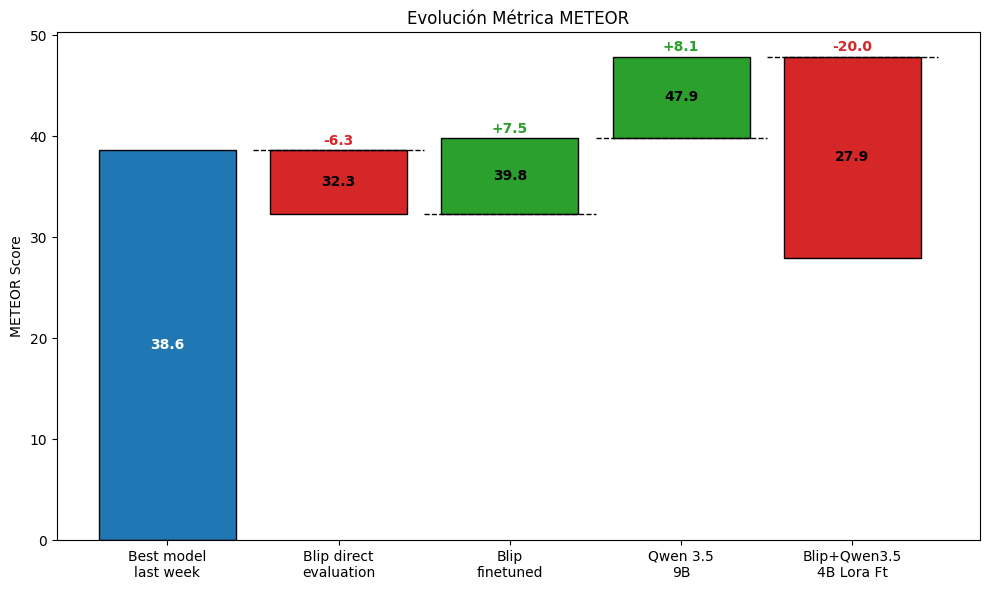

In [3]:
import matplotlib.pyplot as plt
import numpy as np

labels = ["Best model\nlast week", "Blip direct\nevaluation", "Blip\nfinetuned", "Qwen 3.5\n9B", "Blip+Qwen3.5\n4B Lora Ft"]
values = [38.6, 32.3, 39.8, 47.9, 27.9]

# Calcular los cambios (step)
step = [values[0]]
for i in range(1, len(values)):
    step.append(values[i] - values[i-1])

fig, ax = plt.subplots(figsize=(10, 6))

# Calcular las bases (bottoms) para apilar las barras flotantes
bottoms = []
for i in range(len(values)):
    if i == 0:
        bottoms.append(0)
    else:
        bottoms.append(values[i-1] if step[i] > 0 else values[i])

# Asignar colores: Azul inicial, Verde (mejora), Rojo (empeoramiento)
colors = ['#1f77b4'] + ['#2ca02c' if s > 0 else '#d62728' for s in step[1:]]

# Dibujar las barras
ax.bar(labels, np.abs(step), bottom=bottoms, color=colors, edgecolor='black')

# Añadir las líneas punteadas que conectan los escalones
for i in range(1, len(values)):
    ax.plot([i-0.5, i+0.5], [values[i-1], values[i-1]], color='black', linestyle='--', linewidth=1)

# Añadir textos
for i, (v, b, s) in enumerate(zip(values, bottoms, step)):
    y_pos = b + abs(s)/2 if i!=0 else v/2
    ax.text(i, y_pos, f"{v}", ha='center', va='center', color='white' if i==0 else 'black', fontweight='bold')
    if i != 0:
        delta_text = f"+{s:.1f}" if s > 0 else f"{s:.1f}"
        ax.text(i, max(values[i], values[i-1]) + 0.5, delta_text, ha='center', color=colors[i], fontweight='bold')

ax.set_ylabel("METEOR Score")
ax.set_title("Evolución Métrica METEOR")
plt.tight_layout()
plt.show()